In [30]:
%load_ext autoreload
%autoreload 2

#Import Libraries
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import shape
import os
import ee
import geemap
import time
import joblib

from Glance_Class_Definitions import class1_dict, class2_dict
from Embedding_Utils import get_embeddings, EMBEDDING_BANDS, get_patch_arrays, align_patch_arrays
from Random_Forest import split_data, fit_random_forest, fit_xgboost, tune_random_forest, tune_xgboost, rf_validation_curve, _LabelDecodingClassifier
from MLP import fit_mlp, _MLPClassifier
from CNN import fit_cnn, _CNNClassifier
from Constants import DATA_DIR, MODEL_DIR
from Evaluation import plot_feature_importances, evaluate_model, compare_models, plot_training_curve, plot_validation_curve

#Initiate GEE Project
ee.Initialize(project='turnkey-lacing-391919')

#Define Variables
start_year = 2017
download_embeddings = True #If True, sample any missing years' embeddings from GEE; if False, only load years already cached locally
refit_models = True # When set to True, this will cause the models to be refit. Available saved models will be loaded when False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
#Read in Glance Data

geojson_path = os.path.join('Data', 'bu_glance_training_dataV1.geojson')
#https://www.nature.com/articles/s41597-023-02798-5#Sec10
#https://source.coop/boston-university/bu-glance

# Large file (~1.1 GB / ~1.87M features) — pyogrio is the fast, memory-efficient reader.
glance = gpd.read_file(geojson_path, engine='pyogrio')


In [3]:
#Filter Glance Data
glance_NA = glance.loc[glance['Continent_Code']==1,] # Filter to just North America

glance_NA_filtered = glance_NA.loc[glance_NA['End_Year']>=start_year,]
print(glance_NA_filtered['Glance_Class_ID_level1'].isna().sum()==0) #Make sure that there are No NAs present

glance_NA_filtered = glance_NA_filtered[['Lat','Lon','Glance_ID','Start_Year','End_Year','Glance_Class_ID_level1','Glance_Class_ID_level2','geometry']]

end_year = glance_NA_filtered['End_Year'].unique().max()

True


In [4]:
#Per Year Explosion
expanded_Glance = glance_NA_filtered.copy()

# AlphaEarth embeddings only exist for 2017 onward, so clip each segment's year
# range to [max(Start_Year, 2017), End_Year] before exploding — otherwise segments
# that start well before 2017 (but end after) generate years with no embedding to join.
expanded_Glance['Year'] = expanded_Glance.apply(
    lambda r: list(range(max(int(r['Start_Year']), start_year), int(r['End_Year']) + 1)),
    axis=1
)

expanded_Glance = expanded_Glance.drop(columns=['Start_Year', 'End_Year'])

expanded_Glance = expanded_Glance.explode('Year', ignore_index=True)

expanded_Glance_Class1 = expanded_Glance.drop(columns = ['Glance_Class_ID_level2'])

expanded_Glance_Class2 = expanded_Glance.loc[expanded_Glance['Glance_Class_ID_level2'] != 0,] #Remove unknown values
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns = ['Glance_Class_ID_level1'])
print([0] not in expanded_Glance_Class2['Glance_Class_ID_level2'].unique()) #Double check no more 0's 
print(expanded_Glance_Class1.shape[0] > expanded_Glance_Class2.shape[0]) #Confirm that rows were dropped
print(expanded_Glance_Class1['Year'].min(), expanded_Glance_Class1['Year'].max()) #Confirm year range is within AlphaEarth availability


True
True
2017 2021


In [5]:
#Read in Embeddings and Organize
embeddings_dir = os.path.join('Data', 'Embeddings')

# Drop any embedding columns from a prior run of this cell so it's safe to re-run
# without first re-running the per-year-explosion cell above.
expanded_Glance_Class1 = expanded_Glance_Class1.drop(columns=EMBEDDING_BANDS, errors='ignore')
expanded_Glance_Class2 = expanded_Glance_Class2.drop(columns=EMBEDDING_BANDS, errors='ignore')

# Class1 is the superset of Class2 rows, so sample/cache once against it and join into both.
unique_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()

embeddings_df = get_embeddings(unique_year_points, cache_dir=embeddings_dir, download_embeddings=download_embeddings)
embeddings_df['Year'] = embeddings_df['Year'].astype(expanded_Glance_Class1['Year'].dtype)

#Join embeddings onto both class tables by (Glance_ID, Year)
expanded_Glance_Class1 = expanded_Glance_Class1.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')
expanded_Glance_Class2 = expanded_Glance_Class2.merge(embeddings_df, on=['Glance_ID', 'Year'], how='inner')

print(f'Class1 rows with embeddings: {expanded_Glance_Class1.shape[0]} / {unique_year_points.shape[0]}')
print(f'Class2 rows with embeddings: {expanded_Glance_Class2.shape[0]}')
print(f'{expanded_Glance_Class1[EMBEDDING_BANDS].isna().sum().sum()} missing embedding values')


Loading cached embeddings for 2017 from Data/Embeddings/embeddings_2017.csv
Loading cached embeddings for 2018 from Data/Embeddings/embeddings_2018.csv
Loading cached embeddings for 2019 from Data/Embeddings/embeddings_2019.csv
Loading cached embeddings for 2020 from Data/Embeddings/embeddings_2020.csv
Loading cached embeddings for 2021 from Data/Embeddings/embeddings_2021.csv
Class1 rows with embeddings: 64004 / 64004
Class2 rows with embeddings: 48092
0 missing embedding values


In [6]:
#Split data into training and test
expanded_Glance_Class1_Clean = expanded_Glance_Class1.drop(columns = ["geometry","Year","Lat","Lon"])
                                                 
x_train, x_test, y_train, y_test = split_data(expanded_Glance_Class1_Clean, "Glance_Class_ID_level1")
print(x_train.head())


         A00       A01       A02       A03       A04       A05       A06  \
0   0.098424 -0.038447 -0.093564 -0.199862 -0.251965 -0.135886  0.160000   
1   0.098424 -0.098424 -0.113741 -0.141730 -0.228897 -0.179377  0.199862   
10  0.059116 -0.119093 -0.172795 -0.079723 -0.206936 -0.179377  0.166336   
11  0.024606 -0.113741 -0.130165 -0.038447 -0.186082 -0.179377  0.192910   
12  0.029773 -0.130165 -0.071111 -0.153787 -0.186082 -0.041584  0.079723   

         A07       A08       A09  ...       A54       A55       A56       A57  \
0   0.013841 -0.153787  0.267958  ...  0.024606 -0.135886  0.108512 -0.098424   
1  -0.048228 -0.172795  0.221453  ...  0.010396 -0.124567  0.160000 -0.041584   
10  0.008858 -0.179377  0.236463  ...  0.084214 -0.147697  0.075356 -0.006151   
11 -0.055363 -0.186082  0.221453  ...  0.075356 -0.160000  0.098424 -0.022207   
12 -0.051734 -0.179377  0.236463  ...  0.079723 -0.024606  0.059116 -0.032541   

         A58       A59       A60       A61       A62    

Model saved to ./Model_Outputs/random_forest_model.joblib
Training time: 12.34 seconds
               precision    recall  f1-score   support

        Water      0.990     0.986     0.988       841
    Developed      0.970     0.958     0.964      1153
Barren/Sparse      0.916     0.887     0.901       882
        Trees      0.971     0.968     0.970      5054
       Shrubs      0.772     0.898     0.830      1576
   Herbaceous      0.969     0.940     0.954      6523

     accuracy                          0.946     16029
    macro avg      0.931     0.939     0.935     16029
 weighted avg      0.949     0.946     0.947     16029

Overall accuracy : 0.946
Balanced accuracy: 0.939
Macro F1         : 0.935


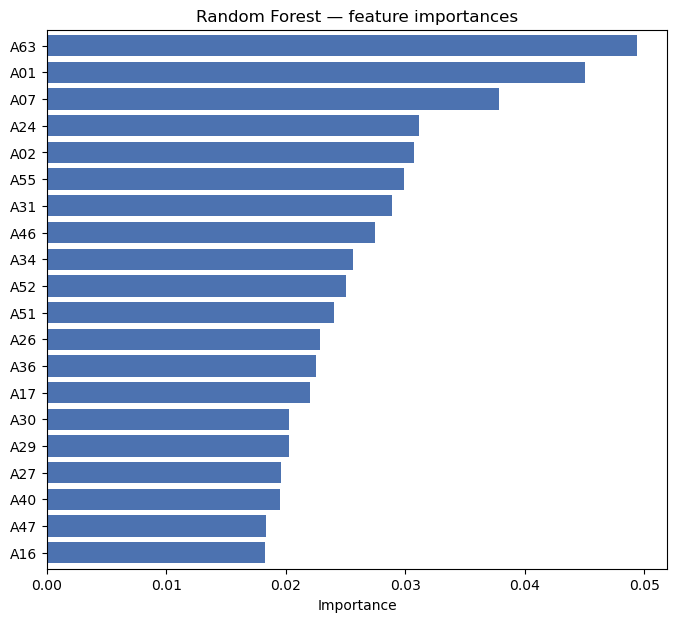

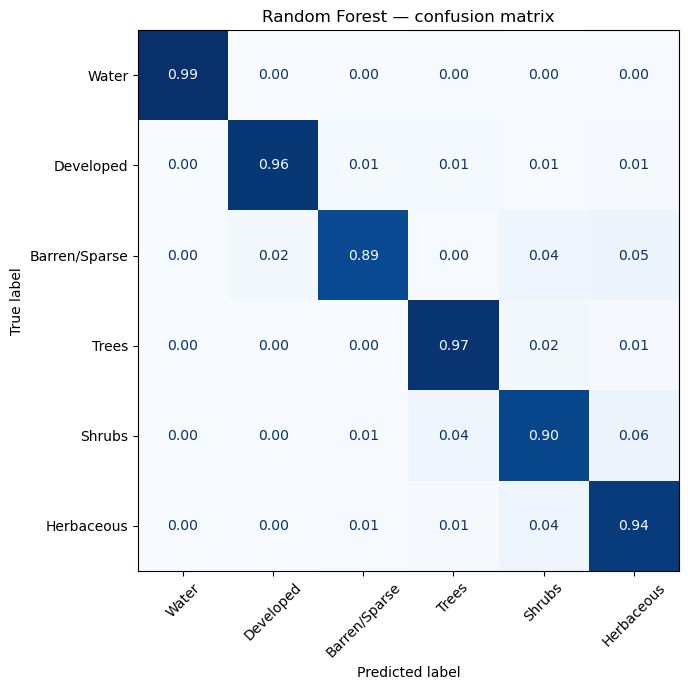

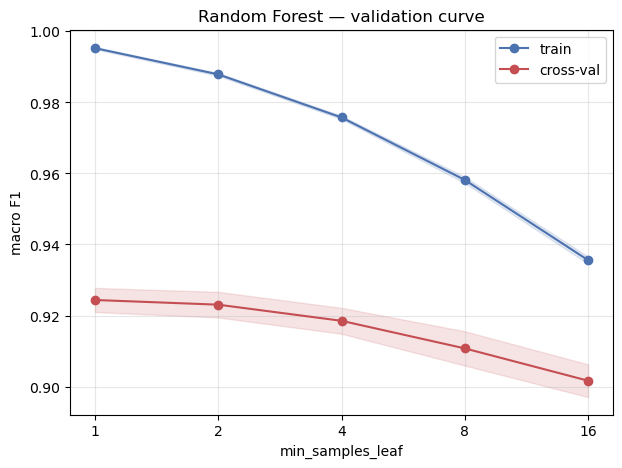

In [19]:
#Fit model
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = ""
filename = f'random_forest_model{filename_ext}.joblib'

# ── Fit or load model ─────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_random_forest(x_train, y_train)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'random_forest_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'random_forest_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest — feature importances',
    save_path=os.path.join(MODEL_DIR, f'random_forest_importances{filename_ext}.png'))
rf_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Random Forest — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'random_forest_confusion{filename_ext}.png'))

# ── Overfitting diagnostic ────────────────────────────────────────────────────
# A Random Forest has no epochs, so instead of a loss curve we plot a grouped-CV
# validation curve: train vs CV macro-F1 as min_samples_leaf varies. A wide
# train-minus-CV gap at small min_samples_leaf indicates overfitting. (Runs a
# small grouped search, so it takes a bit.)
if refit_models:
    groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]
    vc_param, vc_train, vc_val = rf_validation_curve(
        x_train, y_train, groups_train, param_name='min_samples_leaf',
        param_range=(1, 2, 4, 8, 16))
    plot_validation_curve(
        vc_param, vc_train, vc_val, param_name='min_samples_leaf', scoring='macro F1',
        title='Random Forest — validation curve',
        save_path=os.path.join(MODEL_DIR, f'random_forest_valcurve{filename_ext}.png'))


Model saved to ./Model_Outputs/XGBoost_model.joblib
Training time: 2.03 seconds
               precision    recall  f1-score   support

        Water      0.987     0.983     0.985       841
    Developed      0.977     0.955     0.966      1153
Barren/Sparse      0.917     0.895     0.906       882
        Trees      0.974     0.968     0.971      5054
       Shrubs      0.783     0.878     0.828      1576
   Herbaceous      0.965     0.948     0.957      6523

     accuracy                          0.947     16029
    macro avg      0.934     0.938     0.935     16029
 weighted avg      0.949     0.947     0.948     16029

Overall accuracy : 0.947
Balanced accuracy: 0.938
Macro F1         : 0.935


<Axes: title={'center': 'XGBoost — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

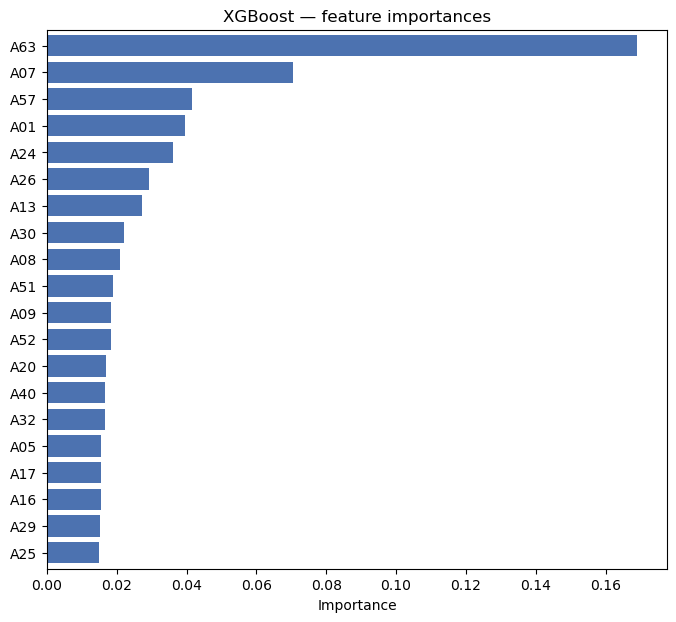

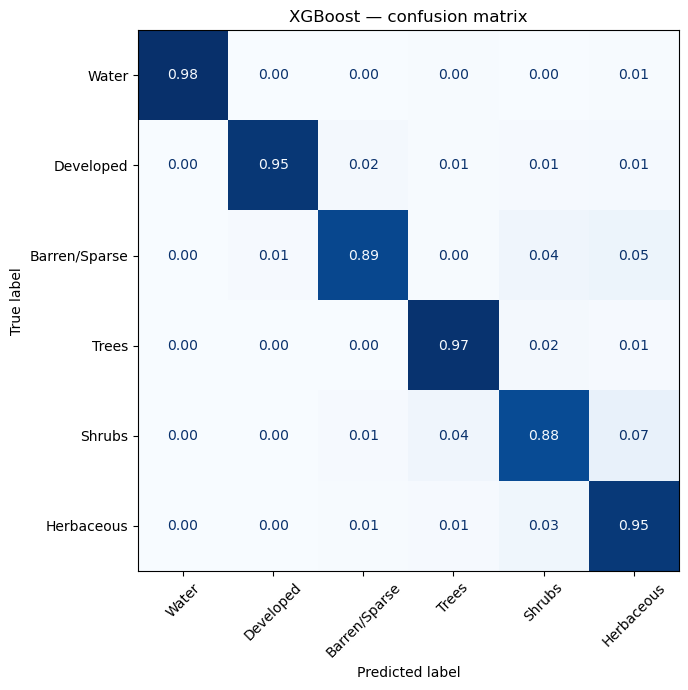

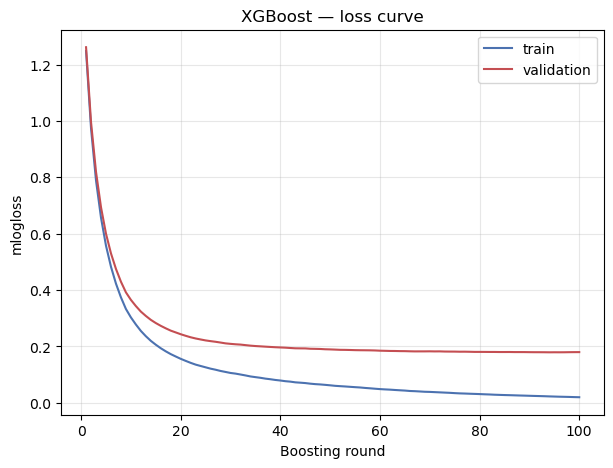

In [20]:
#XGBoost
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = ""
filename = f'XGBoost_model{filename_ext}.joblib'

# Glance_ID groups so fit_xgboost can hold out a grouped validation split for the
# boosting-round loss curve (no segment spans train/val).
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_xgboost(x_train, y_train, groups=groups_train)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'XGBoost_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'XGBoost_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='XGBoost — feature importances',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_importances{filename_ext}.png'))
xgb_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='XGBoost — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val mlogloss per boosting round ──────────
# (history is stored on the model when fit with groups; a loaded model may lack it)
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost — loss curve',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_losscurve{filename_ext}.png'))
#Overfitting 

Search time: 717.81 seconds
               precision    recall  f1-score   support

        Water      0.988     0.985     0.986       841
    Developed      0.970     0.959     0.965      1153
Barren/Sparse      0.922     0.884     0.903       882
        Trees      0.972     0.968     0.970      5054
       Shrubs      0.771     0.893     0.828      1576
   Herbaceous      0.968     0.941     0.954      6523

     accuracy                          0.945     16029
    macro avg      0.932     0.939     0.934     16029
 weighted avg      0.948     0.945     0.946     16029

Overall accuracy : 0.945
Balanced accuracy: 0.939
Macro F1         : 0.934


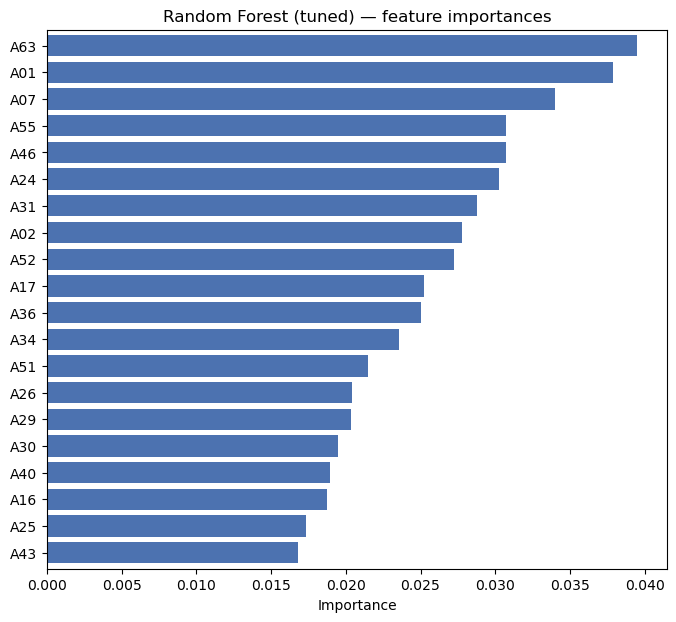

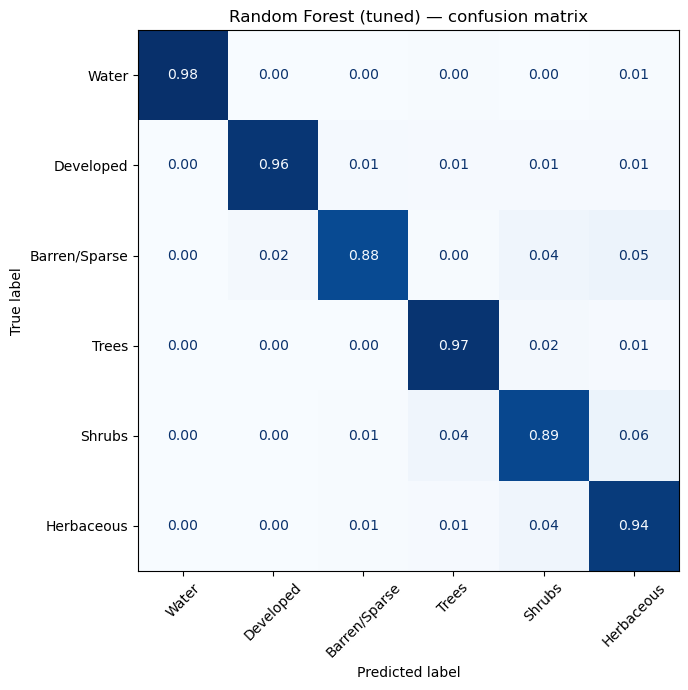

In [11]:
#Random Forest — grouped-CV hyperparameter search
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = "_groupedCV"
filename = f'random_forest_tuned_model{filename_ext}.joblib'

# Glance_ID groups for the training rows (recovered via x_train's index so that
# no segment spans CV folds). Class1 is the target here, so use the Class1 table.
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec, best_params = tune_random_forest(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'random_forest_tuned_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
        f.write(f'best_params: {best_params}\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'random_forest_tuned_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
plot_feature_importances(
    mdl, x_train, title='Random Forest (tuned) — feature importances',
    save_path=os.path.join(MODEL_DIR, f'random_forest_tuned_importances{filename_ext}.png'))
rf_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Random Forest (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'random_forest_tuned_confusion{filename_ext}.png'))


Best params: {'subsample': 0.6, 'reg_lambda': 0.5, 'reg_alpha': 0, 'min_child_weight': 5, 'max_depth': 8, 'max_delta_step': 3, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.8}
Model saved to ./Model_Outputs/XGBoost_tuned_model_groupedCV.joblib
Search time: 127.77 seconds
Early stopping chose best_iteration=437 (of up to 2000 rounds)
               precision    recall  f1-score   support

        Water      0.985     0.987     0.986       841
    Developed      0.979     0.965     0.972      1153
Barren/Sparse      0.910     0.897     0.903       882
        Trees      0.974     0.971     0.972      5054
       Shrubs      0.799     0.882     0.839      1576
   Herbaceous      0.968     0.950     0.959      6523

     accuracy                          0.950     16029
    macro avg      0.936     0.942     0.939     16029
 weighted avg      0.952     0.950     0.951     16029

Overall accuracy : 0.950
Balanced accuracy: 0.942
Macro F1         : 0.939


<Axes: title={'center': 'XGBoost (tuned) — loss curve'}, xlabel='Boosting round', ylabel='mlogloss'>

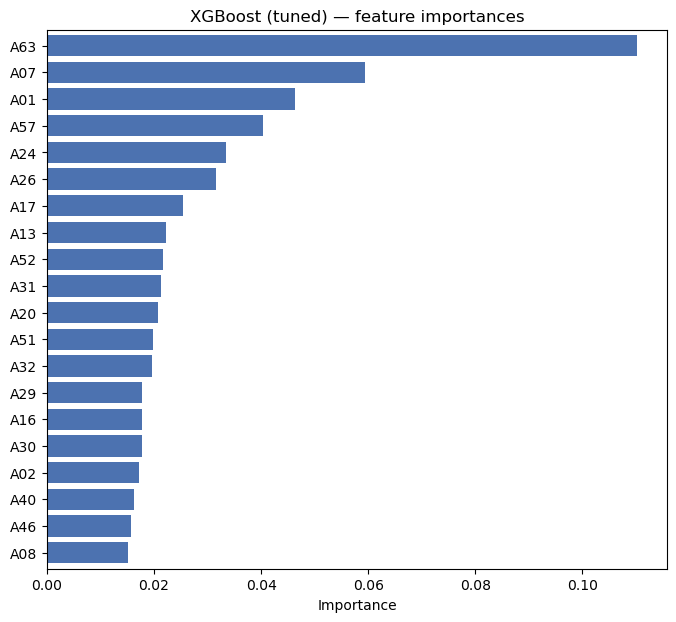

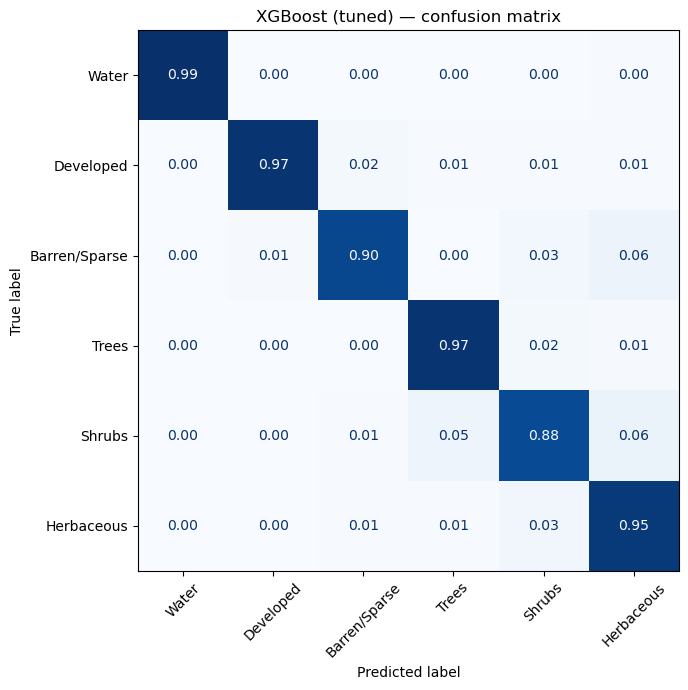

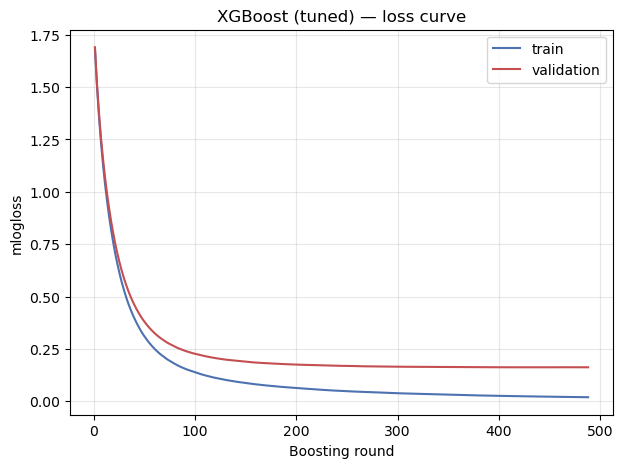

In [26]:
#XGBoost — grouped-CV hyperparameter search
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = "_groupedCV"
filename = f'XGBoost_tuned_model{filename_ext}.joblib'

# Glance_ID groups for the training rows (recovered via x_train's index so that
# no segment spans CV folds).
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
# tune_xgboost searches depth/learning_rate/subsample/gamma/reg_alpha/
# max_delta_step/... (n_estimators is NOT tuned) and refits the winner with a high
# n_estimators cap + early stopping on a grouped val split, so the number of
# boosting rounds is chosen by validation mlogloss instead of tuned.
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec, best_params = tune_xgboost(x_train, y_train, groups_train)
    print(f'Best params: {best_params}')
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'XGBoost_tuned_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
        f.write(f'best_params: {best_params}\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'XGBoost_tuned_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Search time: {training_time_sec:.2f} seconds')
best_iter = getattr(mdl, 'best_iteration', None)
if best_iter is not None:
    print(f'Early stopping chose best_iteration={best_iter} (of up to 2000 rounds)')
plot_feature_importances(
    mdl, x_train, title='XGBoost (tuned) — feature importances',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_importances{filename_ext}.png'))
xgb_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='XGBoost (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val mlogloss per boosting round ──────────
# Validation mlogloss was climbing after a point -> now handled by early stopping;
# the curve should flatten/stop near best_iteration.
plot_training_curve(
    getattr(mdl, 'history_', None), title='XGBoost (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'XGBoost_tuned_losscurve{filename_ext}.png'))


epoch 10/100  train 0.1738  val 0.1627
epoch 20/100  train 0.1455  val 0.1603
epoch 30/100  train 0.1310  val 0.1682
epoch 40/100  train 0.1231  val 0.1734
epoch 50/100  train 0.1132  val 0.1809
epoch 60/100  train 0.1061  val 0.1894
epoch 70/100  train 0.1042  val 0.1907
epoch 80/100  train 0.1025  val 0.1966
epoch 90/100  train 0.0936  val 0.2037
epoch 100/100  train 0.0904  val 0.2096
Model saved to ./Model_Outputs/MLP_model.joblib
Training time: 73.09 seconds
               precision    recall  f1-score   support

        Water      0.966     0.993     0.979       841
    Developed      0.964     0.970     0.967      1153
Barren/Sparse      0.847     0.908     0.876       882
        Trees      0.979     0.960     0.970      5054
       Shrubs      0.720     0.905     0.802      1576
   Herbaceous      0.978     0.917     0.946      6523

     accuracy                          0.937     16029
    macro avg      0.909     0.942     0.923     16029
 weighted avg      0.944     0.937 

<Axes: title={'center': 'Shallow MLP — loss curve'}, xlabel='Epoch', ylabel='Loss'>

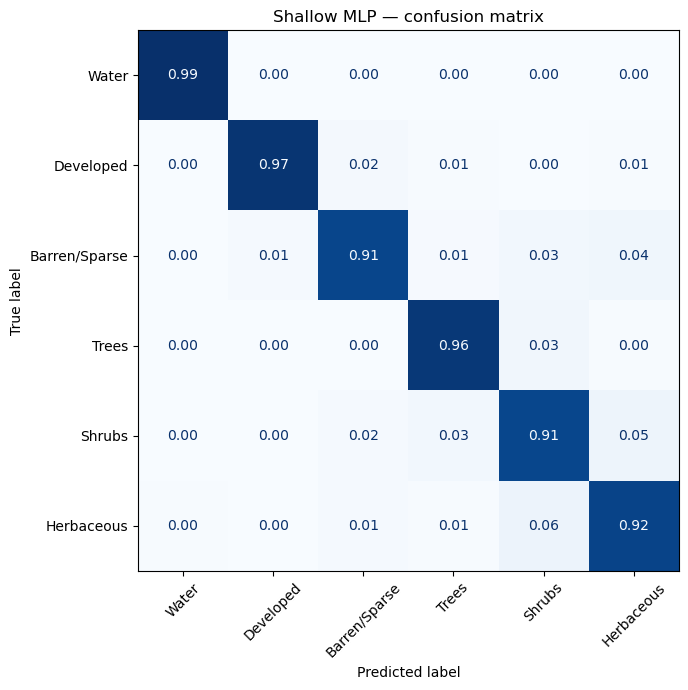

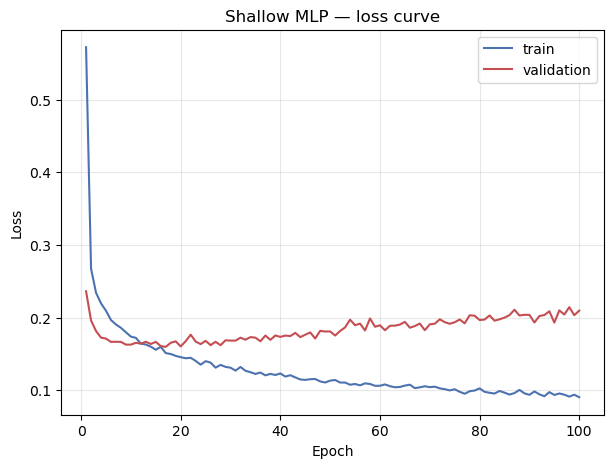

In [22]:
#Shallow MLP (PyTorch)
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = ""
filename = f'MLP_model{filename_ext}.joblib'

# Glance_ID groups so fit_mlp can hold out a grouped validation split for the
# train/val loss curve (no segment spans train/val).
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_mlp(x_train, y_train, groups=groups_train, verbose=True, epochs=100)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
# (No feature-importance plot: an MLP has no built-in feature_importances_.)
print(f'Training time: {training_time_sec:.2f} seconds')
mlp_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Shallow MLP — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'MLP_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val loss per epoch ───────────────────────
# (history is stored on the model when fit with groups; a loaded model may lack it)
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP — loss curve',
    save_path=os.path.join(MODEL_DIR, f'MLP_losscurve{filename_ext}.png'))


epoch 10/300  train 0.1738  val 0.1627
epoch 20/300  train 0.1455  val 0.1603
epoch 30/300  train 0.1310  val 0.1682
early stopping at epoch 32; best epoch 17 (val 0.1597)
Model saved to ./Model_Outputs/MLP_model_tuned.joblib
Training time: 22.46 seconds
Early stopping restored best epoch 17
               precision    recall  f1-score   support

        Water      0.968     0.994     0.981       841
    Developed      0.948     0.975     0.961      1153
Barren/Sparse      0.851     0.899     0.874       882
        Trees      0.984     0.949     0.966      5054
       Shrubs      0.694     0.901     0.784      1576
   Herbaceous      0.975     0.916     0.945      6523

     accuracy                          0.932     16029
    macro avg      0.903     0.939     0.919     16029
 weighted avg      0.941     0.932     0.935     16029

Overall accuracy : 0.932
Balanced accuracy: 0.939
Macro F1         : 0.919


<Axes: title={'center': 'Shallow MLP (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

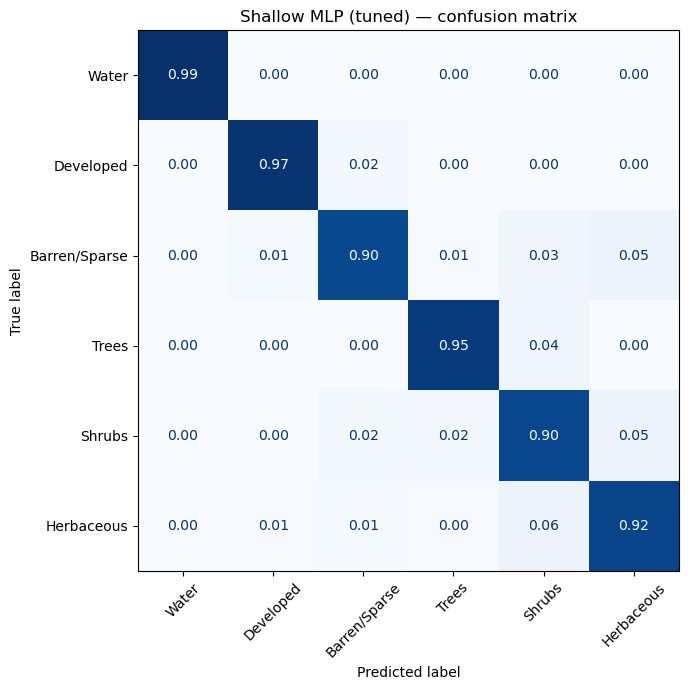

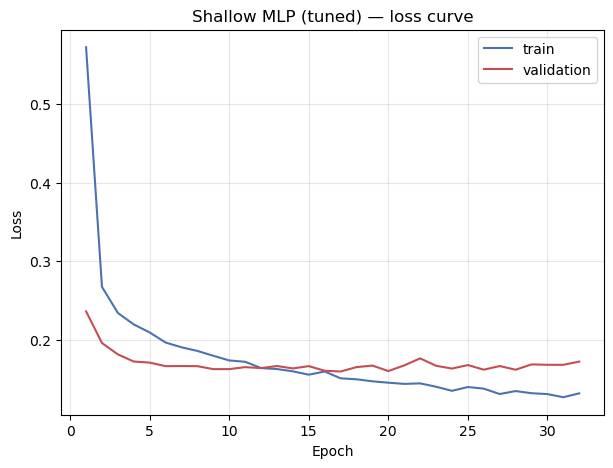

In [29]:
#Shallow MLP (tuned — early stopping)
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = "_tuned"
filename = f'MLP_model{filename_ext}.joblib'

# Glance_ID groups so fit_mlp can hold out a grouped validation split to early-stop on.
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
# High epoch cap + early stopping: training stops when val loss stops improving
# and the best-epoch weights are restored (see model.best_epoch_).
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_mlp(x_train, y_train, groups=groups_train,
                                     early_stopping_rounds=15, epochs=300, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'MLP_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
mlp_tuned_metrics = evaluate_model(
    mdl, x_test, y_test, class_map=class1_dict,
    title='Shallow MLP (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'MLP_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val loss per epoch (stops near best epoch) ─
plot_training_curve(
    getattr(mdl, 'history_', None), title='Shallow MLP (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'MLP_losscurve{filename_ext}.png'))


In [23]:
#Patch Embeddings (for CNN)
# Sample the raw k x k x 64 embedding window around each point (radius=2 -> 5x5).
# The aligned full array (X_patch_all) is cached to Data/ and reloaded if present,
# so the sampling + alignment is not repeated on every run.
patch_dir = os.path.join('Data', 'Embeddings_Patch')
patch_radius = 2
patch_all_path = os.path.join('Data', f'X_patch_all_r{patch_radius}.npy')

if os.path.exists(patch_all_path):
    X_patch_all = np.load(patch_all_path)
    print(f'Loaded cached X_patch_all from {patch_all_path}: {X_patch_all.shape}')

# Recompute if there is no cache, or the cache no longer matches the current rows.
if not os.path.exists(patch_all_path) or X_patch_all.shape[0] != len(expanded_Glance_Class1):
    patch_year_points = expanded_Glance_Class1[['Glance_ID', 'Year', 'Lat', 'Lon']].drop_duplicates()
    patch_arrays, patch_keys = get_patch_arrays(
        patch_year_points, cache_dir=patch_dir, radius=patch_radius,
        download_embeddings=download_embeddings)
    # Reorder windows to match expanded_Glance_Class1's row order.
    X_patch_all = align_patch_arrays(patch_arrays, patch_keys,
                                     expanded_Glance_Class1[['Glance_ID', 'Year']])
    np.save(patch_all_path, X_patch_all)
    print(f'Saved X_patch_all to {patch_all_path}: {X_patch_all.shape}')

# Reuse the existing train/test split on the aligned patch array.
X_train_patch = X_patch_all[x_train.index.values]
X_test_patch = X_patch_all[x_test.index.values]

print(f'Patch windows: {X_patch_all.shape}  (n, k, k, channels)')
print(f'Train/test patches: {X_train_patch.shape} / {X_test_patch.shape}')
print(f'Missing (all-NaN) patches in train: {int(np.isnan(X_train_patch).all(axis=(1, 2, 3)).sum())}')


Loaded cached X_patch_all from Data/X_patch_all_r2.npy: (64004, 5, 5, 64)
Patch windows: (64004, 5, 5, 64)  (n, k, k, channels)
Train/test patches: (47975, 5, 5, 64) / (16029, 5, 5, 64)
Missing (all-NaN) patches in train: 0


epoch 10/40  train 0.1434  val 0.1838
epoch 20/40  train 0.1096  val 0.2127
epoch 30/40  train 0.0913  val 0.2268
epoch 40/40  train 0.0791  val 0.2603
Model saved to ./Model_Outputs/CNN_model.joblib
Training time: 72.31 seconds
               precision    recall  f1-score   support

        Water      0.970     0.995     0.982       841
    Developed      0.962     0.955     0.958      1153
Barren/Sparse      0.865     0.912     0.887       882
        Trees      0.977     0.960     0.969      5054
       Shrubs      0.740     0.876     0.802      1576
   Herbaceous      0.969     0.930     0.949      6523

     accuracy                          0.938     16029
    macro avg      0.914     0.938     0.925     16029
 weighted avg      0.943     0.938     0.940     16029

Overall accuracy : 0.938
Balanced accuracy: 0.938
Macro F1         : 0.925


<Axes: title={'center': 'CNN (patches) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

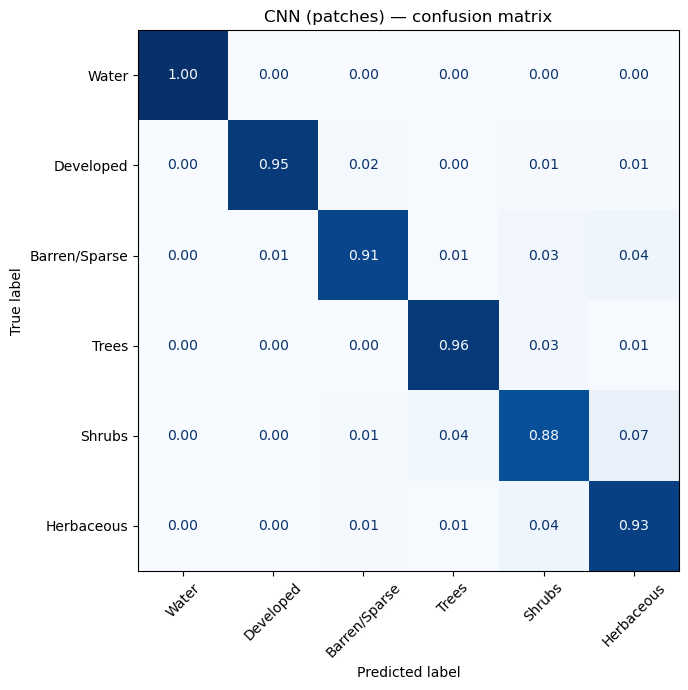

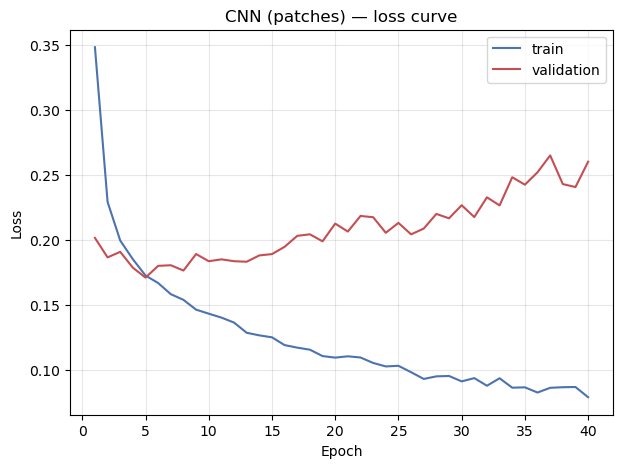

In [24]:
#CNN (PyTorch, embedding patches)
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = ""
filename = f'CNN_model{filename_ext}.joblib'

# Glance_ID groups (aligned to x_train rows, same rows as the patches) so fit_cnn
# can hold out a grouped validation split for the train/val loss curve.
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_cnn(X_train_patch, y_train, groups=groups_train, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
# (No feature-importance plot: a CNN has no built-in feature_importances_.)
print(f'Training time: {training_time_sec:.2f} seconds')
cnn_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class1_dict,
    title='CNN (patches) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'CNN_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val loss per epoch ───────────────────────
# (history is stored on the model when fit with groups; a loaded model may lack it)
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (patches) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'CNN_losscurve{filename_ext}.png'))


epoch 10/200  train 0.1434  val 0.1838
early stopping at epoch 15; best epoch 5 (val 0.1712)
Model saved to ./Model_Outputs/CNN_model_tuned.joblib
Training time: 25.27 seconds
Early stopping restored best epoch 5
               precision    recall  f1-score   support

        Water      0.975     0.994     0.985       841
    Developed      0.945     0.963     0.954      1153
Barren/Sparse      0.824     0.923     0.871       882
        Trees      0.977     0.959     0.968      5054
       Shrubs      0.703     0.888     0.785      1576
   Herbaceous      0.976     0.907     0.940      6523

     accuracy                          0.931     16029
    macro avg      0.900     0.939     0.917     16029
 weighted avg      0.939     0.931     0.933     16029

Overall accuracy : 0.931
Balanced accuracy: 0.939
Macro F1         : 0.917


<Axes: title={'center': 'CNN (tuned) — loss curve'}, xlabel='Epoch', ylabel='Loss'>

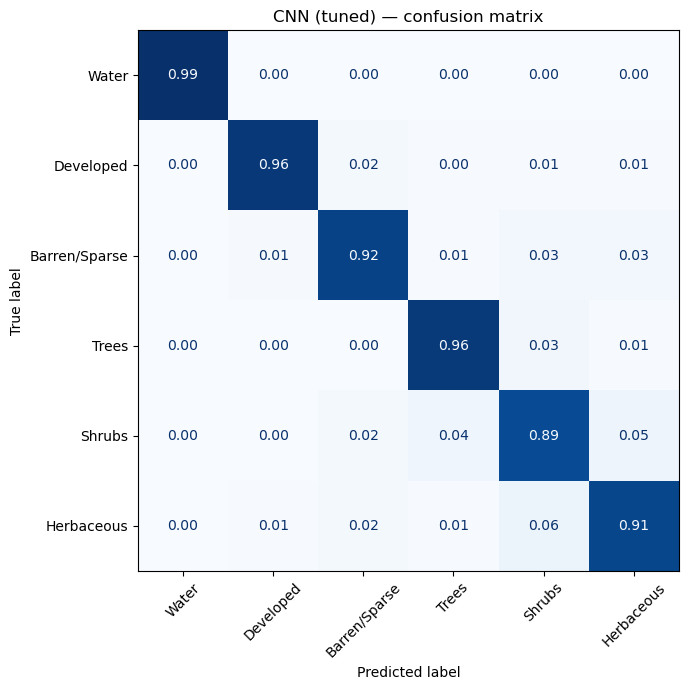

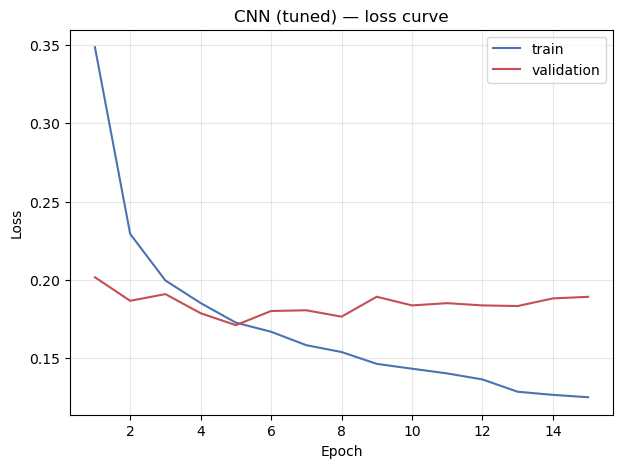

In [31]:
#CNN (tuned — early stopping)
# ── Variant filename and extension ────────────────────────────────────────────
filename_ext = "_tuned"
filename = f'CNN_model{filename_ext}.joblib'

# Glance_ID groups (aligned to x_train / patch rows) for the grouped val split to early-stop on.
groups_train = expanded_Glance_Class1_Clean.loc[x_train.index, "Glance_ID"]

# ── Fit or load model ─────────────────────────────────────────────────────────
# High epoch cap + early stopping: training stops when val loss stops improving
# and the best-epoch weights are restored (see model.best_epoch_).
if refit_models or not os.path.exists(os.path.join(MODEL_DIR, filename)):
    mdl, training_time_sec = fit_cnn(X_train_patch, y_train, groups=groups_train,
                                     early_stopping_rounds=10, epochs=200, verbose=True)
    joblib.dump(mdl, os.path.join(MODEL_DIR, filename))
    print(f'Model saved to {MODEL_DIR}/{filename}')
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt'), 'w') as f:
        f.write(f'{training_time_sec:.2f} seconds\n')
else:
    mdl = joblib.load(os.path.join(MODEL_DIR, filename))
    with open(os.path.join(MODEL_DIR, f'CNN_training_time{filename_ext}.txt')) as f:
        training_time_sec = float(f.read().split()[0])

# ── Evaluate ──────────────────────────────────────────────────────────────────
print(f'Training time: {training_time_sec:.2f} seconds')
best_epoch = getattr(mdl, 'best_epoch_', None)
if best_epoch is not None:
    print(f'Early stopping restored best epoch {best_epoch + 1}')
cnn_tuned_metrics = evaluate_model(
    mdl, X_test_patch, y_test, class_map=class1_dict,
    title='CNN (tuned) — confusion matrix',
    save_path=os.path.join(MODEL_DIR, f'CNN_confusion{filename_ext}.png'))

# ── Overfitting diagnostic: train vs val loss per epoch (stops near best epoch) ─
plot_training_curve(
    getattr(mdl, 'history_', None), title='CNN (tuned) — loss curve',
    save_path=os.path.join(MODEL_DIR, f'CNN_losscurve{filename_ext}.png'))


=== Summary metrics (saved to model_comparison_summary.csv) ===


,Accuracy,Balanced accuracy,Macro F1,Weighted F1,Training time (s)
Random Forest,0.9456,0.9394,0.9346,0.9466,12.34
XGBoost,0.9471,0.9379,0.9354,0.9479,2.03
RF (tuned),0.9455,0.9385,0.9343,0.9464,717.81
XGBoost (tuned),0.9501,0.9420,0.9386,0.9507,127.77
MLP,0.9369,0.9423,0.9235,0.9389,73.09
MLP (tuned),0.9324,0.9390,0.9185,0.9349,22.46
CNN,0.9384,0.9379,0.9246,0.9399,72.31
CNN (tuned),0.9309,0.9389,0.9170,0.9332,25.27



=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned)
Water,0.9881,0.9851,0.9863,0.9857,0.9795,0.9806,0.9824,0.9847
Developed,0.9638,0.9658,0.9647,0.9721,0.9667,0.9611,0.9582,0.9540
Barren/Sparse,0.9009,0.9059,0.9028,0.9035,0.8764,0.8743,0.8874,0.8706
Trees,0.9699,0.9710,0.9700,0.9723,0.9695,0.9663,0.9686,0.9678
Shrubs,0.8304,0.8280,0.8275,0.8386,0.8024,0.7843,0.8019,0.7846
Herbaceous,0.9543,0.9566,0.9544,0.9592,0.9464,0.9447,0.9494,0.9405


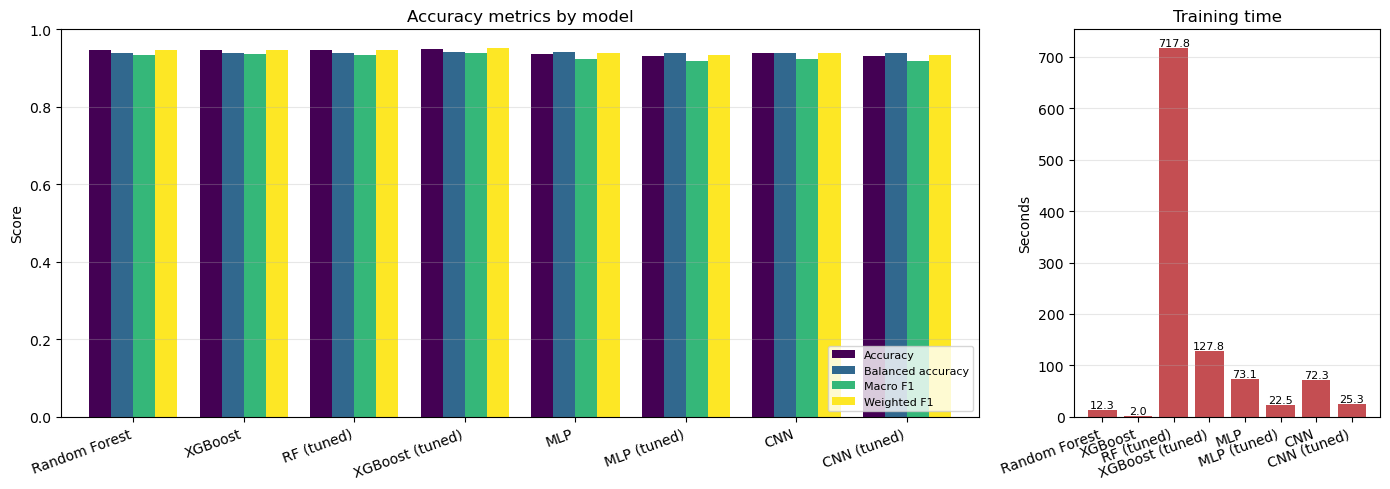

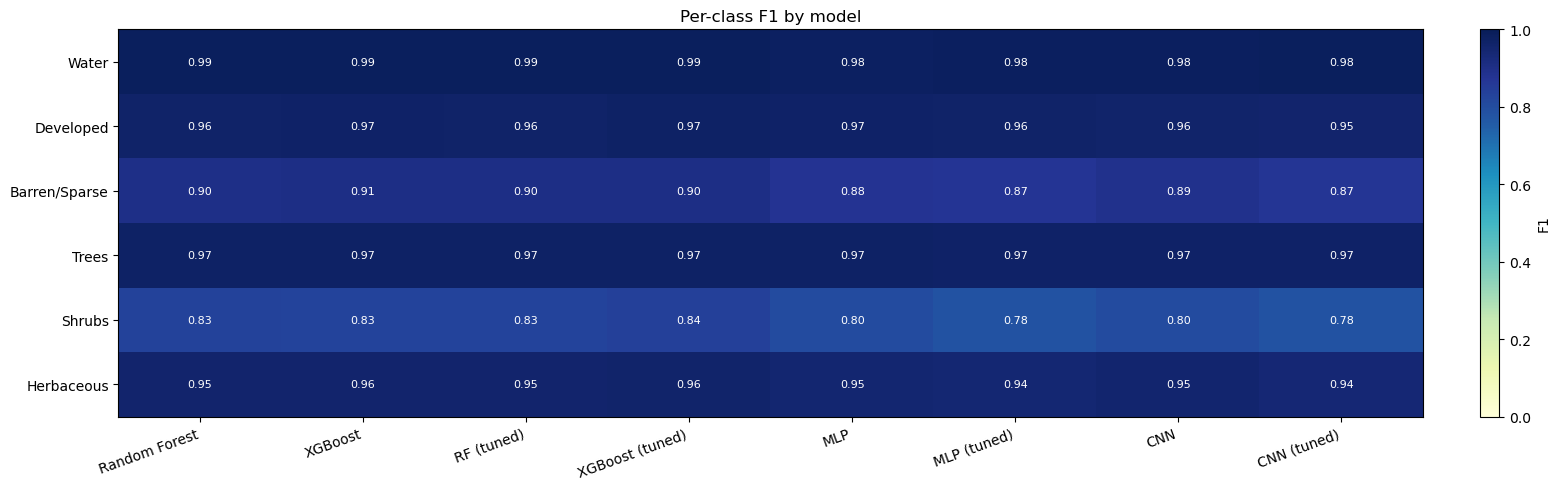

In [32]:
#Compare Models
# Load the already-fitted models and their recorded training times from disk
# (no refitting here) and compare them on the shared held-out test set.

def _load_training_time(time_filename):
    with open(os.path.join(MODEL_DIR, time_filename)) as f:
        return float(f.read().split()[0])  # first token of "<seconds> seconds"

# Display name -> (model filename, training-time filename). These are the exact
# filenames written by the fit/tune cells (the tuned ones used a "_groupedCV" ext).
model_files = {
    'Random Forest':   ('random_forest_model.joblib',                  'random_forest_training_time.txt'),
    'XGBoost':         ('XGBoost_model.joblib',                        'XGBoost_training_time.txt'),
    'RF (tuned)':      ('random_forest_tuned_model_groupedCV.joblib',  'random_forest_tuned_training_time_groupedCV.txt'),
    'XGBoost (tuned)': ('XGBoost_tuned_model_groupedCV.joblib',        'XGBoost_tuned_training_time_groupedCV.txt'),
    'MLP':             ('MLP_model.joblib',                            'MLP_training_time.txt'),
    'MLP (tuned)':     ('MLP_model_tuned.joblib',                      'MLP_training_time_tuned.txt'),
}

# These models all take the shared single-pixel x_test.
models = {}
for name, (model_file, time_file) in model_files.items():
    model = joblib.load(os.path.join(MODEL_DIR, model_file))
    models[name] = (model, _load_training_time(time_file))

# The CNN variants take patch windows, so pass their own test set as a 3-tuple
# override (same rows as y_test). Requires the Patch Embeddings cell to have run.
cnn_model = joblib.load(os.path.join(MODEL_DIR, 'CNN_model.joblib'))
models['CNN'] = (cnn_model, _load_training_time('CNN_training_time.txt'), X_test_patch)
cnn_tuned_model = joblib.load(os.path.join(MODEL_DIR, 'CNN_model_tuned.joblib'))
models['CNN (tuned)'] = (cnn_tuned_model, _load_training_time('CNN_training_time_tuned.txt'), X_test_patch)

summary_df, per_class_f1_df = compare_models(
    models, x_test, y_test, class_map=class1_dict,
    save_dir=MODEL_DIR, prefix='model_comparison')

print('=== Summary metrics (saved to model_comparison_summary.csv) ===')
display(summary_df.round(4))
print('\n=== Per-class F1 (saved to model_comparison_per_class_f1.csv) ===')
display(per_class_f1_df.round(4))


WA/OR observations by split:
  Training: 2354 of 47975 (WA=1017, OR=1337)
  Test:     753 of 16029 (WA=321, OR=432)

Evaluating on 753 WA/OR test observations...

=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===


,Accuracy,Balanced accuracy,Macro F1,Weighted F1,Training time (s)
Random Forest,0.9363,0.9376,0.9348,0.9372,12.34
XGBoost,0.9376,0.9151,0.9227,0.9383,2.03
RF (tuned),0.9336,0.9387,0.9328,0.9352,717.81
XGBoost (tuned),0.9376,0.9340,0.9334,0.9388,127.77
MLP,0.9203,0.9315,0.9221,0.9238,73.09
MLP (tuned),0.9031,0.9261,0.9023,0.9074,22.46
CNN,0.9349,0.9315,0.9274,0.9363,72.31
CNN (tuned),0.9031,0.9245,0.9020,0.9066,25.27



=== WA/OR per-class F1 ===


,Random Forest,XGBoost,RF (tuned),XGBoost (tuned),MLP,MLP (tuned),CNN,CNN (tuned)
Water,1.0000,0.9375,1.0000,1.0000,1.0000,0.9714,1.0000,1.0000
Developed,0.9293,0.9091,0.9293,0.9293,0.9109,0.9126,0.9091,0.9109
Barren/Sparse,0.9457,0.9375,0.9457,0.9365,0.9683,0.9242,0.9147,0.8794
Trees,0.9819,0.9839,0.9778,0.9819,0.9817,0.9734,0.9879,0.9736
Shrubs,0.8205,0.8290,0.8119,0.8122,0.7570,0.7364,0.8182,0.7512
Herbaceous,0.9312,0.9391,0.9324,0.9403,0.9145,0.8956,0.9348,0.8969


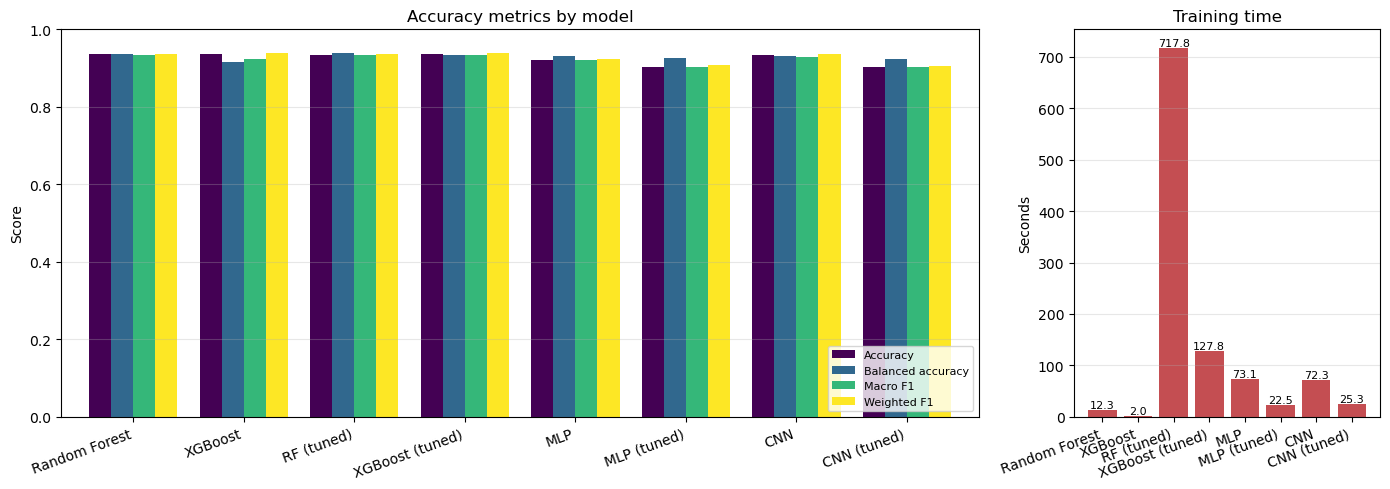

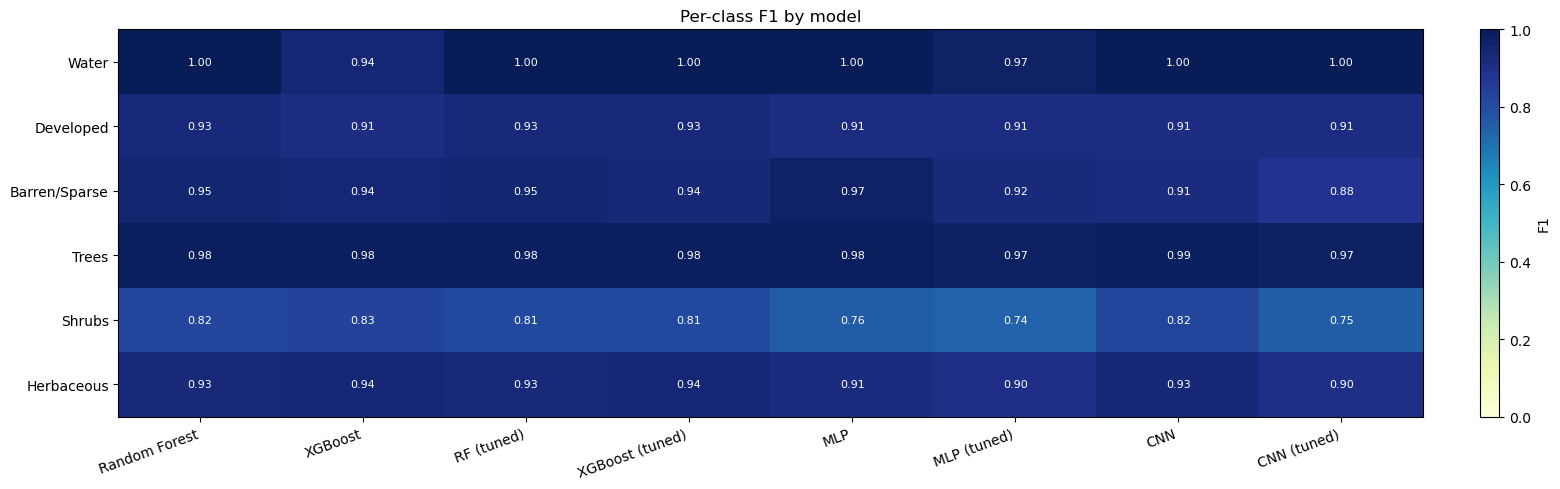

In [33]:
#Compare Models — Washington/Oregon subset
# How many WA/OR observations are in train vs test, and how well do the models
# predict the WA/OR observations within the test set? Reuses the models loaded
# in the cell above.

# WA/OR polygons (same TIGER source as the Extra cell).
wa_or_fc = (ee.FeatureCollection('TIGER/2018/States')
            .filter(ee.Filter.inList('NAME', ['Washington', 'Oregon'])))
wa_or_states = gpd.GeoDataFrame.from_features(
    wa_or_fc.getInfo()['features'], crs='EPSG:4326')[['NAME', 'geometry']]

# Point-in-polygon test for every Class1 row (they retain Lat/Lon), aligned by index.
pts = gpd.GeoDataFrame(
    expanded_Glance_Class1[['Glance_ID']].copy(),
    geometry=gpd.points_from_xy(expanded_Glance_Class1['Lon'], expanded_Glance_Class1['Lat']),
    crs='EPSG:4326')
joined = gpd.sjoin(pts, wa_or_states, predicate='within', how='left')
joined = joined[~joined.index.duplicated(keep='first')]  # guard against border points matching both
state_of = joined['NAME'].reindex(expanded_Glance_Class1.index)
in_wa_or = state_of.notna()

# Counts in train vs test.
train_state, test_state = state_of.loc[x_train.index], state_of.loc[x_test.index]
print('WA/OR observations by split:')
print(f"  Training: {int(in_wa_or.loc[x_train.index].sum())} of {len(x_train)} "
      f"(WA={int((train_state == 'Washington').sum())}, OR={int((train_state == 'Oregon').sum())})")
print(f"  Test:     {int(in_wa_or.loc[x_test.index].sum())} of {len(x_test)} "
      f"(WA={int((test_state == 'Washington').sum())}, OR={int((test_state == 'Oregon').sum())})")

# Restrict the test set to WA/OR and re-run the same comparison.
mask = in_wa_or.loc[x_test.index].values  # aligned to x_test / X_test_patch row order
x_test_wa_or = x_test[mask]
y_test_wa_or = y_test[mask]
X_test_patch_wa_or = X_test_patch[mask]

models_wa_or = dict(models)  # reuse the already-loaded models + training times
# Re-point the patch-input CNN variants at the WA/OR patch subset.
models_wa_or['CNN'] = (cnn_model, models['CNN'][1], X_test_patch_wa_or)
models_wa_or['CNN (tuned)'] = (cnn_tuned_model, models['CNN (tuned)'][1], X_test_patch_wa_or)

print(f'\nEvaluating on {int(mask.sum())} WA/OR test observations...')
summary_wa_or_df, per_class_wa_or_df = compare_models(
    models_wa_or, x_test_wa_or, y_test_wa_or, class_map=class1_dict,
    save_dir=MODEL_DIR, prefix='model_comparison_WA_OR')

print('\n=== WA/OR summary metrics (saved to model_comparison_WA_OR_summary.csv) ===')
display(summary_wa_or_df.round(4))
print('\n=== WA/OR per-class F1 ===')
display(per_class_wa_or_df.round(4))


In [43]:
#Extra (KEEP AND DON'T EDIT)

# Washington and Oregon boundaries from GEE (TIGER 2018 state boundaries).
states_fc = (ee.FeatureCollection('TIGER/2018/States')
    .filter(ee.Filter.inList('NAME', ['Washington', 'Oregon'])))
states = gpd.GeoDataFrame.from_features(
    states_fc.getInfo()['features'], crs='EPSG:4326'
)[['NAME', 'geometry']]

# glance is already loaded and in EPSG:4326 from the previous cell.
glance_wa_or = gpd.sjoin(glance, states, predicate='within', how='inner')

counts = glance_wa_or['NAME'].value_counts()
for state in ['Washington', 'Oregon']:
    print(f'{state}: {counts.get(state, 0)}')
print(f'Total (WA + OR): {len(glance_wa_or)}')

#glance_wa_or.head()
print(glance.columns)
glance_NA = glance.iloc[glance['Continent_Code']==1,]
print(glance_NA.shape)
print(glance_NA['Glance_Class_ID_level2'].value_counts())

print(glance_NA.shape[0])
Class1 = []
Class2 = []
for i in range(0,glance_NA.shape[0]):
    key = glance_NA['Glance_Class_ID_level1'].iloc[i]
    Class1 = Class1 + [class1_dict[key]]
    key2 = glance_NA['Glance_Class_ID_level2'].iloc[i]
    #print(class2_dict[key2])
    Class2 = Class2 + [class2_dict[key2]]
glance_NA['Class1'] = Class1
glance_NA['Class2'] = Class2
#print(glance_NA.head())
print(glance_NA['Class2'].value_counts())
#print(glance_NA['Glance_Class_ID_level2'].unique())
glance_NA_0 = glance_NA.iloc[glance_NA['Class2']=="Unknown",]
print(glance_NA_0['Class1'].value_counts())

print(glance_NA_filtered['Change'].value_counts())
test = glance_NA_filtered.iloc[glance_NA_filtered['Change'],]
#print(test.head())
test['End_Year'].value_counts()

counts = glance_NA_filtered[['Lat', 'Lon']].value_counts().reset_index(name='count')
print(counts['count'].value_counts())

test2 = glance_NA_filtered.iloc[glance_NA_filtered['Segment_Type']==0,]
print(test2['Change'].value_counts())

print(glance_NA_filtered['Change'].value_counts())
print(glance_NA_filtered.shape)
print(glance_NA_filtered['Class2'].value_counts())

Index(['Lat', 'Lon', 'Start_Year', 'End_Year', 'Dataset_Code',
       'Continent_Code', 'LC_Confidence', 'Segment_Type', 'Leaf_Type',
       'Impervious_Percent', 'Veg_Density', 'Tree_Location', 'Veg_Modifier',
       'Level1_Ecoregion', 'Level2_Ecoregion', 'Glance_Class_ID_level1',
       'Glance_Class_ID_level2', 'Change', 'ID', 'Glance_ID', 'geometry'],
      dtype='str')
(48014, 21)
Glance_Class_ID_level2
0     12774
11    12517
10     6235
3      3155
1      2987
8      2715
12     2131
9      2100
7      1154
5      1009
4       783
6       234
13      220
Name: count, dtype: int64
48014
Class2
Unknown        12774
Grassland      12517
Shrub           6235
Developed       3155
Water           2987
Evergreen       2715
Agriculture     2131
Mixed           2100
Deciduous       1154
Rock            1009
Soil             783
Beach/Sand       234
Moss/Lichen      220
Name: count, dtype: int64
Class1
Trees            8908
Herbaceous       3050
Barren/Sparse     816
Name: count, dtype: 